# Crypto perpetuals: 400 candidate models from two validation years

[`06_linear`](06_linear.ipynb) worked through what a penalty does to a feature set that is one
economic quantity - the premium of the perpetual over spot - measured many ways. The L1 path
reduced to a single column and the ranking stopped moving. Gradient boosting meets the same
feature set with a different constraint: a tree does not weight columns, it splits on them, and
on a block of near-duplicates it can split on one measurement of the premium after another. That
is a way to describe the training window in great detail without adding any information.

Three dials control how far it goes, and this notebook varies all three:

- **Capacity**, set by `num_leaves`: how many regions one tree may carve the feature space into.
- **The loss function**, which decides what "got wrong" means. Squared error weights an
  observation by the square of its error; absolute error and Huber do not. Eight-hour crypto
  returns are heavy-tailed enough for that to be a real choice rather than a formality.
- **When to stop**, set by the number of trees. A boosted model has a meaningful state at every
  iteration, so this notebook scores each configuration at ten points along its own training run.

**The arithmetic of that is the reason to read this notebook carefully.** The four declared
labels bring fifteen configurations each for the two return horizons and five each for the two
direction cuts - forty in all, at ten checkpoints apiece, which is 400 candidate models. This
case study also has the shortest usable history of the nine: `05_evaluation` set two
walk-forward folds from the liquid funding data that exists, so every one of those 400 numbers
is measured on two validation years of a market whose structure changed over them. The more
candidates a search has, the better its best member looks for reasons that have nothing to do
with the data - and here the candidate count is large while the evidence each candidate is
judged on is small.

The comparison is within a label. A candidate is a (label, configuration, checkpoint) triple,
and nothing below ranks a return model against a direction model as if they were competing for
the same slot; what the labels are compared on is how far each one's own grid gets.

**Learning objectives.** By the end of this notebook you will be able to:

- Read a declared gradient boosting grid and say what each configuration varies.
- Explain why a boosted model produces one result per checkpoint while a linear model produces
  one result in total, and what that implies for counting candidates.
- Read a learning curve of out-of-sample information coefficient against tree count, and say
  whether an apparent peak is a turning point or the highest of ten noisy readings.
- Say why the choice of loss function is a statement about the label's tails, and relate that to
  what a rank-based metric rewards.
- Judge a result by the number of candidates behind it and the amount of validation data under
  it, rather than by its rank in a table.

**Book reference**: Chapter 12, Section 12.2 (GBM libraries) and Section 12.3 (how to tune a
boosted model). Chapter 6, Section 6.7 (Search accounting and run logging) introduces the run
log this notebook writes to, and Section 6.8 the multiple-testing problem this grid creates.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds, and
[`06_linear`](06_linear.ipynb) fitted the linear population this one is compared against.

**What it writes**: one training run per configuration and one complete validation prediction
set per configuration and checkpoint, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`13_backtest`](13_backtest.ipynb) reads that population and selects on validation backtest
Sharpe. **Selection happens there, not here.**

In [1]:
"""Fit the declared crypto perpetuals gradient boosting population on the walk-forward folds."""

import numpy as np
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    primary_label,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""

In [3]:
study = open_study(
    "crypto_perps_funding", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None
)

## 1. Which labels, and which models

The labels are the same ones the linear notebook fitted, and for the same reason: the two
families are compared on identical targets, folds and features, so what separates their results
is the family. Fitting all four here rather than one also carries the linear notebook's finding
forward to be checked - that the sign of the eight-hour move is a far more rankable target than
its size, on the same inputs.

In [4]:
declared_labels(study, "gbm")

('fwd_dir_8h', 'fwd_dir_8h_3c', 'fwd_ret_24h', 'fwd_ret_8h')

Each label's menu at `config/training/{label}.yaml` lists its named configurations under `gbm:`,
and each resolves to a preset in `case_studies/config/lgb/`. The return labels declare fifteen,
a product of two axes; the direction labels declare a shorter list, because some members of the
return grid have no classifier counterpart.

- **Five capacity profiles.** `default` uses the library's own leaf count; the rest fix it at 7,
  15, 31 and 63. Leaf count is the direct control on how finely one tree may partition the
  feature space. On a feature set this redundant the dial does something particular: with many
  near-copies of the premium available, a deeper tree can keep splitting on one measurement of
  it after another and describe the training window in fine detail without adding information.
- **Three objectives.** `mse` minimizes squared error, `mae` absolute error, and `huber` behaves
  like squared error for small residuals and like absolute error beyond a threshold derived from
  each fold's own label spread.

Every configuration runs the same number of boosting iterations with the same learning rate, so
the grid isolates capacity and loss rather than confounding them with training length.

In [5]:
configs = load_model_configs(
    study,
    "gbm",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""gbm""","""fwd_dir_8h""","""default_binary""","""""","""objective=binary, seed=42"""
"""gbm""","""fwd_dir_8h""","""leaves_7_binary""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_dir_8h""","""leaves_15_binary""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_dir_8h""","""leaves_31_binary""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_dir_8h""","""leaves_63_binary""","""""","""bagging_fraction=0.8, bagging_…"
…,…,…,…,…
"""gbm""","""fwd_ret_8h""","""leaves_31_mae""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_8h""","""leaves_31_huber""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_8h""","""leaves_63_mse""","""""","""bagging_fraction=0.8, bagging_…"


`LABELS` and `CONFIG_NAMES` both narrow what is fitted, and a narrowed run declares a different
set of members than the canonical population does. A population is immutable once written, so
such a run must publish under its own name: on a fresh workspace it would otherwise register an
incomplete snapshot under the canonical one, and where the full population already exists the
registry refuses it. Comparing the loaded rows against the complete declared catalog catches
either knob, and says so here rather than several cells later in a message about hashes.

In [6]:
if configs.height < load_model_configs(study, "gbm").height and not POPULATION_NAME:
    raise ValueError(
        f"this run fits {configs.height} of the declared configurations, so it cannot publish "
        "the canonical population; pass POPULATION_NAME to give it its own"
    )

## 2. Binding the declarations to the data

Resolving reads the label and feature files, computes the fold boundaries, works out the exact
rows each fit must predict, and turns any data-dependent parameter into the number it will use.
Huber's threshold is one of those: it is a fraction of the training labels' standard deviation,
so it is a different number on every fold and is resolved from that fold's own data.

Nothing is fitted here, so the plan can be inspected first. Four things to check:

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row.** A row that
  differs is a configuration measured on a different sample from its neighbours.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out tail visible.
- **`checkpoints` is where this differs from the linear plan.** It is the number of training
  states each configuration will publish predictions for. Multiply it by the number of rows to
  get the number of candidate models this notebook is about to create.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,i64,i64,i64,i64,i64,"datetime[μs, UTC]","datetime[μs, UTC]"
"""default_binary""",44,19,35280,2,10,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""leaves_15_binary""",44,19,35280,2,10,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""leaves_31_binary""",44,19,35280,2,10,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""leaves_63_binary""",44,19,35280,2,10,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""leaves_7_binary""",44,19,35280,2,10,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
…,…,…,…,…,…,…,…
"""leaves_63_mae""",44,19,35280,2,10,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""leaves_63_mse""",44,19,35280,2,10,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC
"""leaves_7_huber""",44,19,35280,2,10,2022-01-01 00:00:00 UTC,2023-12-31 08:00:00 UTC


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. casts the design matrix to the precision LightGBM works in and leaves missing values in
   place - a tree routes a missing value down its own branch, so imputing a median here would
   hand the model an observation nobody made,
3. fits the declared number of boosting iterations,
4. predicts the fold's validation rows at each checkpoint, using only the trees built up to that
   iteration.

Step 4 is what makes one fit produce many results. The fold predictions are concatenated into
one series per checkpoint covering the whole validation period, and each becomes its own
registered prediction set with its own identity.

Preparation happens once per fold and is shared by every configuration, because slicing the
window and cleaning the rows depends on the data and not on the model. The run walks folds on
the outside and configurations on the inside for the same reason: one prepared fold is held at a
time rather than the whole set.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

**One population covers every label**, because one run fits every label. A population is
immutable once written, so a notebook fitting one label per run under a single name publishes
the first label and is refused for the second; fitting them together is what lets one name
describe the whole declared set.

In [8]:
population_name = POPULATION_NAME or "crypto_perps_funding-gbm-validation-v1"
execution, population = run_model_population(study, resolved, population_name=population_name)

print(f"{len(execution.runs)} configurations fitted")
print(f"population {population.name}: {len(population.members)} prediction sets")

40 configurations fitted
population crypto_perps_funding-gbm-validation-v1: 400 prediction sets


Re-running this notebook unchanged costs the time it takes to read the data. Every identity is
re-derived from the inputs, the registry already holds the matching rows, and the runner returns
the stored result rather than fitting again.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("crypto_perps_funding", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "gbm", labels=["fwd_ret_8h"], config_names=["leaves_15_huber", "leaves_31_huber"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-gbm-v1")
```

`CONFIG_NAMES` fits a subset of what the menu declares. To fit something new, add a preset at
`case_studies/config/lgb/leaves_127_huber.yaml` and list `leaves_127_huber` under `gbm:` in the
label's menu. Editing an existing preset changes that configuration's identity, so its result
registers as a new row beside the old one rather than replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per configuration and checkpoint. `ic_mean` is the **information coefficient**: on each
validation timestamp, rank the contracts by the model's prediction, rank them by the return they
went on to earn, correlate the two rankings, and average that correlation over the validation
period.

`auc_mean_daily` reads the same predictions the way a classifier is read. At each validation
timestamp, take every pair of one contract that went up and one that went down, and count the
fraction of those pairs the model ranked in the right order; average that over the validation
period, with one half being what a coin achieves. It is computed within each timestamp and then
averaged, the same shape as `ic_mean`, which is what makes the two answer the same question.

`auc_n_days` is smaller than `ic_n_days`, and the gap is structural rather than a data problem.
A pair needs one contract that went up and one that went down, so a timestamp on which the whole
cross-section moved together defines no AUC, while a rank correlation is still defined there.
It costs 540 of 2,189 timestamps here. `full_coverage` refers to `ic_n_days` only.

The two together answer a question neither answers alone. Some of these models are fitted to the
size of the next return and some to its sign: `fwd_dir_8h` is the direction cut from the same
return at the same horizon as `fwd_ret_8h`, and `fwd_dir_8h_3c` cuts it into three. This run
fits all four, so both formulations sit in one catalog on identical folds and features. Which
one suits the data is not settled by argument - a squared-error fit spends its capacity on the
largest returns, and crypto funding returns have a heavy tail - and carrying both readings on
every model lets the comparison be made directly. `06_linear` made it and found the direction
cut far more rankable; the sections below make it again for this family.

The table is sorted by label and then by IC, and the top of each label's block is the trap this
notebook exists to describe. The leading row for a label is the maximum of a configuration count
times ten checkpoints. Reading it as the result of one experiment would attribute to the model
whatever the stopping point contributed, and the section below measures how large that
contribution is before anything is concluded from the ranking.

Coverage is judged against each label's own maximum number of scorable timestamps, because the
labels do not offer the same number: the 24-hour label runs out of forward window earlier than
the eight-hour ones. One global maximum would mark that whole label incomplete for a reason
unrelated to any model. The direction labels are not affected - their IC is computed against the
continuous return, not the binary coding, so they carry the same `ic_n_days` as `fwd_ret_8h`.
What the constant-direction timestamps cost is AUC coverage, which the paragraph above covers.

In [9]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "complete",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "auc_mean_daily",
    "auc_n_days",
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort(["label", "ic_mean"], descending=[False, True])

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("gbm execution returned a partial prediction set")

catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders the panels
# by whichever label it did fit rather than by one that is not there.
panel_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
order_label = panel_labels[0]
# Counting (label, config_name) pairs and not config_name alone: the fifteen regression names are
# declared by both return labels, so counting names would print an arithmetic that does not hold.
print(
    f"{catalog.height} candidate models: "
    f"{catalog.select('label', 'config_name').n_unique()} label-configuration pairs"
)
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each, on {len(panel_labels)} labels")
catalog.select(
    "label",
    "config_name",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "auc_mean_daily",
    "auc_n_days",
    "full_coverage",
).head(15)

400 candidate models: 40 label-configuration pairs
at 10 checkpoints each, on 4 labels


label,config_name,checkpoint_value,ic_mean,ic_std,ic_n_days,auc_mean_daily,auc_n_days,full_coverage
str,str,i64,f64,f64,f64,f64,f64,bool
"""fwd_dir_8h""","""leaves_7_binary""",150,0.02762,0.017953,2189.0,0.512272,1649.0,true
"""fwd_dir_8h""","""leaves_7_binary""",200,0.025938,0.01694,2189.0,0.509523,1649.0,true
"""fwd_dir_8h""","""leaves_7_binary""",400,0.02591,0.01029,2189.0,0.511562,1649.0,true
"""fwd_dir_8h""","""leaves_7_binary""",500,0.025878,0.015461,2189.0,0.511467,1649.0,true
"""fwd_dir_8h""","""leaves_7_binary""",450,0.025733,0.013232,2189.0,0.511783,1649.0,true
…,…,…,…,…,…,…,…,…
"""fwd_dir_8h""","""leaves_15_binary""",300,0.023589,0.008657,2189.0,0.510391,1649.0,true
"""fwd_dir_8h""","""leaves_15_binary""",350,0.02352,0.004218,2189.0,0.509873,1649.0,true
"""fwd_dir_8h""","""leaves_7_binary""",100,0.0235,0.020276,2189.0,0.510361,1649.0,true


### What more trees do

Each line traces one configuration's out-of-sample IC as trees are added to it. This is the
figure the checkpoint dimension exists to produce, and it separates two things a single
end-of-training number cannot.

A line that rises and then falls has an interior optimum: the model was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
without trend around zero never had anything to learn in the first place, and its highest point
is wherever the noise happened to peak. The difference matters, because both produce a
respectable-looking maximum.

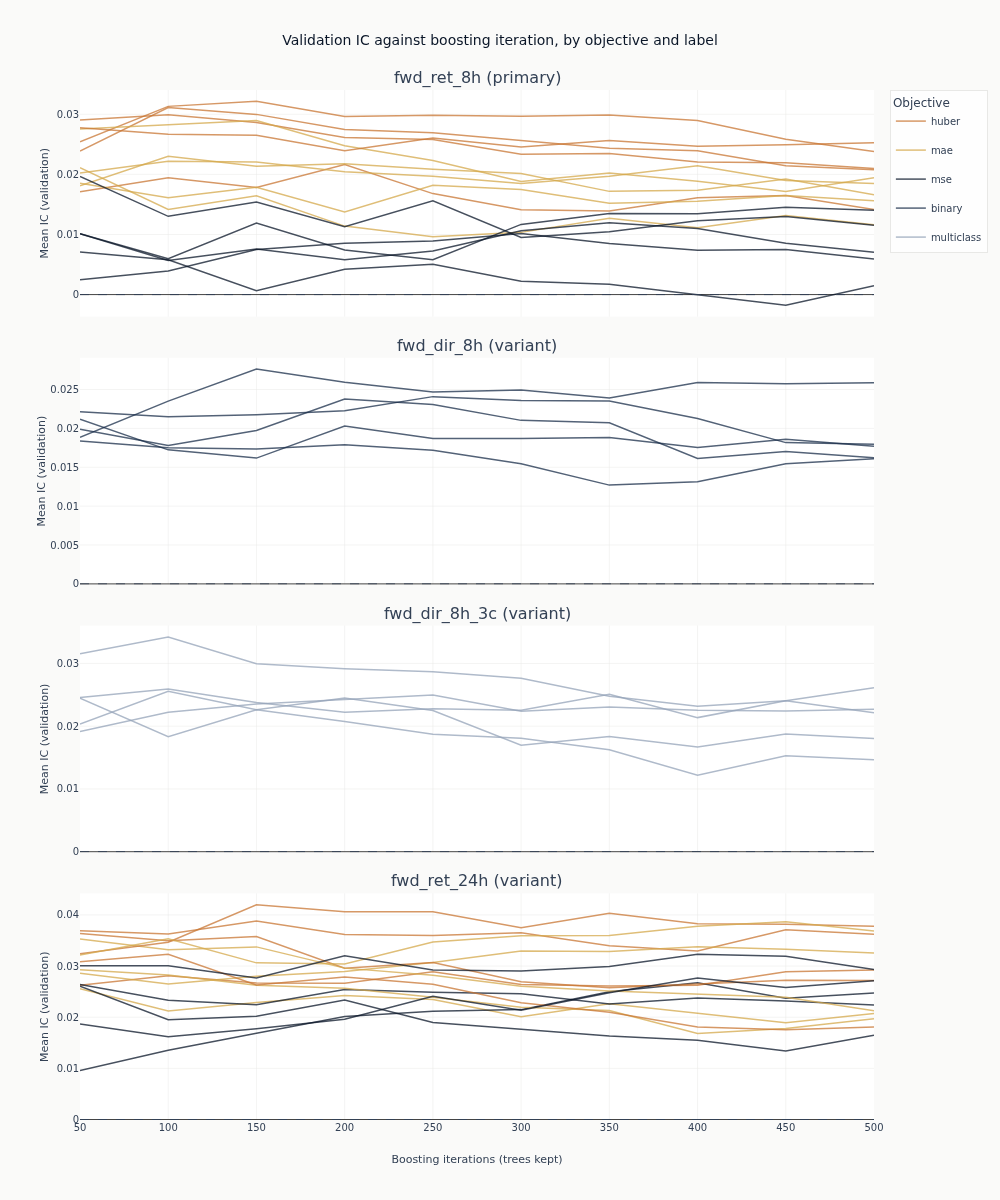

In [10]:
curves = catalog.filter("full_coverage").sort("label", "config_name", "checkpoint_value")
objectives = {
    "mse": COLORS["blue"],
    "mae": COLORS["amber"],
    "huber": COLORS["copper"],
    "binary": COLORS["slate"],
    "multiclass": COLORS["recede"],
}


def objective_of(name: str) -> str:
    """Read the objective out of a declared configuration name.

    The return menus name three regression losses and the direction menus two classification
    ones. Raising on an unrecognised suffix rather than defaulting is deliberate: a default would
    colour a classifier as squared error and the chart would read as a claim about a loss function
    that was never fitted.
    """
    match = next((key for key in objectives if name.endswith(key)), None)
    if match is None:
        raise ValueError(f"{name!r} does not end in a declared objective: {sorted(objectives)}")
    return match


fig_curves = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.04,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
legend_shown: set[str] = set()
for row, label in enumerate(panel_labels, start=1):
    panel = curves.filter(pl.col("label") == label)
    for config_name in panel.get_column("config_name").unique(maintain_order=True):
        series = panel.filter(pl.col("config_name") == config_name)
        objective = objective_of(config_name)
        # One legend entry per objective, not per configuration: the names repeated down four
        # panels would be a legend taller than the chart, and the colour is all it has to explain.
        first_of_objective = objective not in legend_shown
        legend_shown.add(objective)
        fig_curves.add_trace(
            go.Scatter(
                x=series.get_column("checkpoint_value").to_list(),
                y=series.get_column("ic_mean").to_list(),
                mode="lines",
                name=objective,
                legendgroup=objective,
                showlegend=first_of_objective,
                line=dict(color=objectives[objective], width=1.5),
                opacity=0.75,
            ),
            row=row,
            col=1,
        )
    fig_curves.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_curves.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
fig_curves.update_xaxes(title_text="Boosting iterations (trees kept)", row=len(panel_labels), col=1)
fig_curves.update_layout(
    title="Validation IC against boosting iteration, by objective and label",
    height=300 * len(panel_labels),
    width=1000,
    margin=dict(t=90),
    legend=dict(title_text="Objective", font=dict(size=10)),
)
show_plotly_with_alt(
    fig_curves,
    "Stacked line charts of mean validation information coefficient against boosting iteration, "
    "one panel per label, with one line per configuration coloured by objective: blue for squared "
    "error, amber for absolute error, copper for Huber on the return labels, and a single colour "
    "for each direction label, whose menu declares one objective. Each panel carries a dashed zero "
    "line and almost every line in every panel stays above it, one squared-error line dipping "
    "just below at the later checkpoints. In the two return panels the copper Huber lines sit at "
    "the top of the band and the blue squared-error lines at the bottom, separated from the first "
    "checkpoints onwards. Across all four panels most lines reach their highest point early and "
    "drift sideways or down after it.",
)

Whether the lines trend, and which way, is not something to read off a page of overlapping
curves. The frame below measures it: for each configuration, its IC at the last checkpoint minus
its IC at the first, and whether its best checkpoint is an interior one rather than either end.
The interior count is reported and not argued from - the ten readings behind one configuration
are the same model with successively more trees, so the position of the maximum of such a path
piles up at the ends even with no trend at all.

In [11]:
drift = (
    curves.group_by("label", "config_name")
    .agg(
        first_ic=pl.col("ic_mean").sort_by("checkpoint_value").first(),
        last_ic=pl.col("ic_mean").sort_by("checkpoint_value").last(),
        peak_checkpoint=pl.col("checkpoint_value").sort_by("ic_mean", descending=True).first(),
        first_checkpoint=pl.col("checkpoint_value").min(),
        last_checkpoint=pl.col("checkpoint_value").max(),
    )
    .with_columns(
        change=pl.col("last_ic") - pl.col("first_ic"),
        interior_peak=pl.col("peak_checkpoint").is_between(
            pl.col("first_checkpoint"), pl.col("last_checkpoint"), closed="none"
        ),
    )
)
trees_effect = (
    drift.group_by("label")
    .agg(
        configurations=pl.len(),
        median_change=pl.col("change").median(),
        ended_lower=(pl.col("change") < 0).sum(),
        interior_peaks=pl.col("interior_peak").sum(),
        median_peak_checkpoint=pl.col("peak_checkpoint").median(),
    )
    .sort("label")
)
trees_effect

label,configurations,median_change,ended_lower,interior_peaks,median_peak_checkpoint
str,u32,f64,u32,u32,f64
"""fwd_dir_8h""",5,-0.003465,4,3,150.0
"""fwd_dir_8h_3c""",5,-0.002273,3,3,100.0
"""fwd_ret_24h""",15,-0.000737,9,8,150.0
"""fwd_ret_8h""",15,-0.002953,13,10,100.0


### Whether the loss function is what separates them

The curves are coloured by objective because that is the axis with a mechanism behind it. If
heavy tails are steering the squared-error fits, the three colours should separate, and they
should separate more as trees are added, since each additional tree is fitted to the residuals
the previous ones left.

The chart below drops the checkpoint dimension by taking each configuration's final state, so
every configuration is compared at the same amount of training. That is the comparison that does
not require choosing anything after the fact.

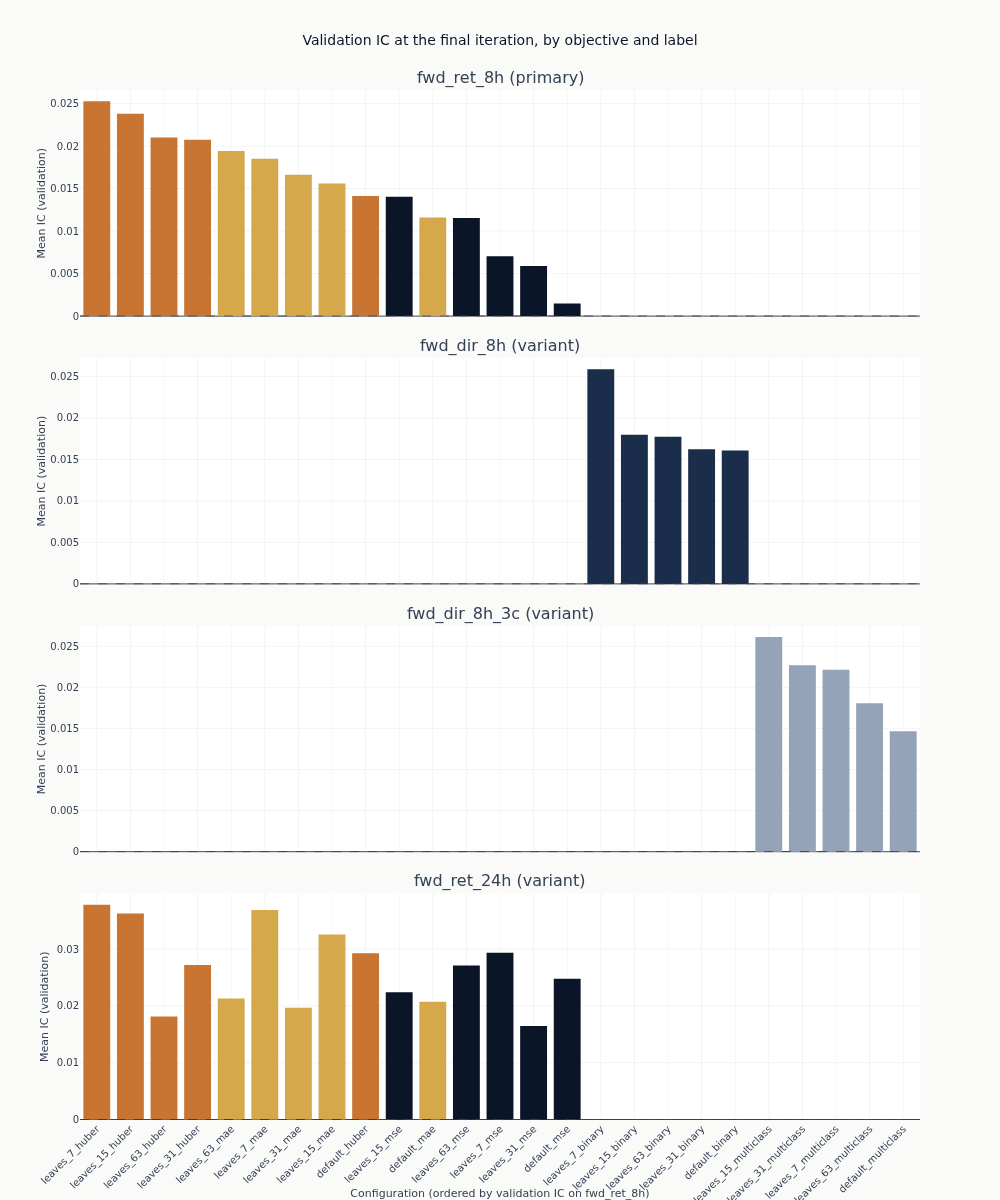

In [12]:
final = (
    catalog.filter(pl.col("checkpoint_value") == pl.col("checkpoint_value").max().over("label"))
    .filter("full_coverage")
    .with_columns(objective=pl.col("config_name").map_elements(objective_of, return_dtype=pl.Utf8))
    .sort(["label", "ic_mean"], descending=[False, True])
)
final_iteration = int(final.get_column("checkpoint_value").max())
config_order = (
    final.filter(pl.col("label") == order_label)
    .sort("ic_mean", descending=True)
    .get_column("config_name")
    .to_list()
)

fig_obj = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.04,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
for row, label in enumerate(panel_labels, start=1):
    panel = final.filter(pl.col("label") == label)
    fig_obj.add_trace(
        go.Bar(
            x=panel.get_column("config_name").to_list(),
            y=panel.get_column("ic_mean").to_list(),
            marker_color=[objectives[value] for value in panel.get_column("objective")],
        ),
        row=row,
        col=1,
    )
    fig_obj.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_obj.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
fig_obj.update_xaxes(
    categoryorder="array",
    categoryarray=config_order,
    tickangle=-45,
    title_text=f"Configuration (ordered by validation IC on {order_label})",
    row=len(panel_labels),
    col=1,
)
fig_obj.update_layout(
    title="Validation IC at the final iteration, by objective and label",
    height=300 * len(panel_labels),
    width=1000,
    showlegend=False,
    margin=dict(t=90),
)
show_plotly_with_alt(
    fig_obj,
    "Stacked bar charts of mean validation information coefficient at the final boosting "
    "iteration, one panel per label, coloured by objective. Every bar in every panel is above the "
    f"dashed zero line. The configurations are in the same order in each panel, that order being "
    f"their ranking on {order_label}; the return labels and the direction labels declare disjoint "
    "menus, so each panel fills its own part of the axis and leaves the rest empty. In the two "
    "return panels the colours group rather than interleave, with copper Huber bars at the left "
    "of the ranking, amber absolute-error bars in the middle and blue squared-error bars at the "
    "right. The two direction panels declare one objective each, so they are single-coloured and "
    "their bar order is the capacity ordering.",
)

The colours in that chart are the claim, so here is the claim as numbers: at the final
iteration, each objective's mean and best IC and how many of its configurations finished above
zero, per label. The ordering the heavy-tailed case studies show is Huber highest, absolute
error next, squared error lowest.

In [13]:
objective_summary = (
    final.group_by("label", "objective")
    .agg(
        configurations=pl.len(),
        mean_ic=pl.col("ic_mean").mean(),
        best_ic=pl.col("ic_mean").max(),
        above_zero=(pl.col("ic_mean") > 0).sum(),
    )
    .sort(["label", "mean_ic"], descending=[False, True])
)
objective_summary

label,objective,configurations,mean_ic,best_ic,above_zero
str,str,u32,f64,f64,u32
"""fwd_dir_8h""","""binary""",5,0.018774,0.025878,5
"""fwd_dir_8h_3c""","""multiclass""",5,0.02074,0.026139,5
"""fwd_ret_24h""","""huber""",5,0.029717,0.037794,5
"""fwd_ret_24h""","""mae""",5,0.026219,0.036864,5
"""fwd_ret_24h""","""mse""",5,0.024015,0.029325,5
"""fwd_ret_8h""","""huber""",5,0.020984,0.025258,5
"""fwd_ret_8h""","""mae""",5,0.016348,0.019426,5
"""fwd_ret_8h""","""mse""",5,0.007994,0.014025,5


### What each label reached, and what its tails look like

Two frames the section below reads from. The first is the best and worst result each label
reached at the final iteration, which is where the linear notebook's size-against-direction
finding gets checked against a different model class.

The second is the tail weight of each label, because the usual explanation for a loss function
changing a rank measure is the tail: a squared-error fit weights a residual by its square, so one
extreme observation moves the fit more than many ordinary ones, and a rank measure does not
reward chasing it. Excess kurtosis measures that directly - zero is the normal distribution,
larger means more of the variance sits in rare large moves - and it is worth taking before the
explanation is applied rather than after.

Each label's rows are cut at its own `validation_end`, the development boundary its fits were
resolved against. The artifact on disk runs to the end of the data, and measuring across all of
it would put a statistic computed partly on sealed holdout outcomes into a validation-stage
notebook.

In [14]:
horizons = (
    final.group_by("label")
    .agg(
        configurations=pl.len(),
        best_config=pl.col("config_name").sort_by("ic_mean", descending=True).first(),
        best_ic=pl.col("ic_mean").max(),
        worst_ic=pl.col("ic_mean").min(),
        above_zero=(pl.col("ic_mean") > 0).sum(),
    )
    .sort("label")
)
horizons

label,configurations,best_config,best_ic,worst_ic,above_zero
str,u32,str,f64,f64,u32
"""fwd_dir_8h""",5,"""leaves_7_binary""",0.025878,0.01608,5
"""fwd_dir_8h_3c""",5,"""leaves_15_multiclass""",0.026139,0.014663,5
"""fwd_ret_24h""",15,"""leaves_7_huber""",0.037794,0.016475,15
"""fwd_ret_8h""",15,"""leaves_7_huber""",0.025258,0.001485,15


In [15]:
development_end = dict(plan.group_by("label").agg(pl.col("validation_end").max()).iter_rows())
# Only the continuous labels. `fwd_dir_8h` takes two values and `fwd_dir_8h_3c` three, and the
# kurtosis of a two-point distribution is -2 whatever the data does, so reporting it for them
# would put a number in the frame that describes the coding rather than the market.
continuous_labels = [
    label for label in panel_labels if study.labels.get(label).definition.task_type == "regression"
]
tails = pl.DataFrame(
    [
        {
            "label": label,
            "development_end": development_end[label],
            "rows": measured.height,
            "excess_kurtosis": measured.get_column(label).kurtosis(),
        }
        for label in continuous_labels
        for measured in [
            pl.read_parquet(study.labels.get(label).path)
            .filter(pl.col("timestamp") <= development_end[label])
            .drop_nulls(label)
        ]
    ]
)
tails

label,development_end,rows,excess_kurtosis
str,"datetime[μs, UTC]",i64,f64
"""fwd_ret_8h""",2023-12-31 08:00:00 UTC,66604,25.012639
"""fwd_ret_24h""",2023-12-30 16:00:00 UTC,66550,412.248947


### How much the checkpoint moves a configuration

One number per configuration and label: the range its IC covers across its own ten checkpoints.
This is the quantity that decides whether choosing a stopping point is a decision worth making
carefully or one being made by noise. A configuration whose IC varies more across its own
training run than the configurations vary among themselves is one where the checkpoint, not the
model, is doing the ranking.

The frame below reduces that to one comparison per label: how far the configurations spread at a
fixed training length, against how far the median configuration travels across its own
checkpoints. A ratio near one means the two decisions are the same size. The five widest-ranging
configurations at each label follow it.

In [16]:
spread = (
    curves.group_by("label", "config_name")
    .agg(
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
        ic_final=pl.col("ic_mean").filter(pl.col("checkpoint_value") == final_iteration).first(),
    )
    .with_columns(checkpoint_range=pl.col("ic_max") - pl.col("ic_min"))
    .sort(["label", "checkpoint_range"], descending=[False, True])
)
comparison = (
    final.group_by("label")
    .agg(across_configurations=pl.col("ic_mean").max() - pl.col("ic_mean").min())
    .join(
        spread.group_by("label").agg(within_one_configuration=pl.col("checkpoint_range").median()),
        on="label",
    )
    .with_columns(ratio=pl.col("across_configurations") / pl.col("within_one_configuration"))
    .sort("label")
)
comparison

label,across_configurations,within_one_configuration,ratio
str,f64,f64,f64
"""fwd_dir_8h""",0.009799,0.006118,1.601586
"""fwd_dir_8h_3c""",0.011476,0.0089,1.289494
"""fwd_ret_24h""",0.021319,0.009597,2.22144
"""fwd_ret_8h""",0.023773,0.00836,2.84374


In [17]:
spread.group_by("label", maintain_order=True).head(5)

label,config_name,ic_min,ic_max,ic_final,checkpoint_range
str,str,f64,f64,f64,f64
"""fwd_dir_8h""","""leaves_7_binary""",0.018855,0.02762,0.025878,0.008765
"""fwd_dir_8h""","""leaves_31_binary""",0.016136,0.02377,0.016233,0.007634
"""fwd_dir_8h""","""leaves_15_binary""",0.017965,0.024083,0.017965,0.006118
"""fwd_dir_8h""","""default_binary""",0.012704,0.018362,0.01608,0.005657
"""fwd_dir_8h""","""leaves_63_binary""",0.016179,0.021181,0.017716,0.005002
…,…,…,…,…,…
"""fwd_ret_8h""","""leaves_63_mae""",0.017166,0.02897,0.019426,0.011804
"""fwd_ret_8h""","""default_mae""",0.009617,0.021106,0.011605,0.011489
"""fwd_ret_8h""","""leaves_31_huber""",0.020749,0.031125,0.020749,0.010376


## 5. What to notice

**The size-against-direction gap the linear notebook found is a property of that family, not of
these labels.** `06_linear` reached an order of magnitude more on the direction cut of
`fwd_ret_8h` than on the return itself, and concluded that the sign was the far more rankable
target. Read `best_ic` down the `horizons` frame here: the return labels and the direction
labels land in the same range, with every configuration of every label above zero. The two
formulations end up in the same place once the model can
condition one feature on another. What the linear grid measured was its own inability to rank
magnitudes on this feature set, not a fact about what is predictable at this horizon. That
correction is available only because both notebooks now fit all four labels; with one label per
run the two halves of it would have sat in different runs and never met.

**The loss function is the axis that matters on the return labels, and it separates almost
cleanly.** `objective_summary` puts Huber first, absolute error second and squared error last on
both return labels, and the curves show the groups stacked rather than interleaved. The tails
frame supports the usual mechanism here, unlike in some other case studies: `fwd_ret_8h` carries
excess kurtosis around 25 and `fwd_ret_24h` far more than that, so squared error - which weights
an observation by the square of its error - is fitted mostly to the largest moves. The
information coefficient is a rank correlation and cares about order rather than magnitude, so
accuracy on the extremes buys nothing it measures. **An objective is a claim about which errors
matter, and squared error makes a claim this metric does not reward.** The direction menus
declare one objective each and vary only capacity, so their panels isolate leaf count and say
nothing about the loss.

**Most configurations peak early and then drift down.** `trees_effect` gives the median peak
checkpoint as 100 or 150 of the 500 iterations the grid runs, and the median configuration ends
below where it started on every label. On a feature set that is one quantity measured many ways
that is what one would expect: there is not much independent structure to find, and the trees
that follow are splitting on near-copies of columns already used. The practical reading is that
the iteration count in these presets is generous for this data and a shorter schedule would lose
little. The interior-peak count is in the frame but not read as evidence - the ten checkpoints of
one configuration are the same model with more trees, so where the maximum of that path falls
tells you little without a baseline this notebook does not compute.

**The checkpoint still moves the answer, by between a third and two thirds of what the model
choice does.** The comparison frame puts the spread across configurations at fixed training
length against the median configuration's own range across its ten checkpoints, and the ratio
is a small single-digit multiple at every label. So the stopping point is a smaller dial than
the model - but not a negligible one, and the leading row of the table is still the maximum of
a configuration count times ten. The fixed-iteration chart is the comparison that does not
require choosing anything after the fact.

**Two folds is the number to hold on to.** Every statement above rests on two validation years of
a market that changed structurally over them, and the search that produced it had 400 members.
That combination - many candidates, little data - is the one where a best member looks convincing
for reasons unrelated to the data. Nothing here is a small effect measured precisely; it is a
moderate effect measured on a short sample, and the honest summary is the direction rather than
the magnitude. [`12_model_analysis`](12_model_analysis.ipynb) is where the search is accounted
for across families.

**Gradient boosting finds more than the penalty grid did, on every label.** The linear
notebook's return grid sat close to zero and its L1 path reduced to a single volatility column.
Every configuration here is positive at the end of training, and on the return labels the
weakest of them is above anything the linear family reached. A tree can condition one feature on
another, and on this feature set that appears to be worth something a weighted sum of the same
columns is not.

**None of this selects anything.** IC measures whether predictions rank contracts correctly, not
whether a strategy trading them makes money after costs and funding - and those are unusually far
apart here, because funding is a cash flow the holder receives or pays regardless of what the
price does, so a position can pay while its price prediction is wrong. Selection is on validation
backtest Sharpe over the population just published, in [`13_backtest`](13_backtest.ipynb), where
the checkpoint is part of what is selected.

**Known limitations.** Two folds, and a short one at that. The IC is an average of per-timestamp
rank correlations with no adjustment for the serial dependence overlapping eight-hour returns
create, so it is a diagnostic rather than a test, and it carries no interval that would say
whether these configurations differ from one another. The grid varies capacity and loss at a
fixed learning rate. And every number is measured on validation folds already read many times by
the time a case study reaches this notebook.

**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) asks the same question of a neural network built
for tabular data. The thing to watch is whether it prefers the same loss functions - if the tails
are what separates the objectives here, a different model class fitted with the same objectives
should separate the same way.